## Categorical Imputation

### Most frequent Data
1. Change distribution of the data
2. Used when less than 5% MCAR
3. Easy to implement

If Categories are missing more than 10%, we make missing another category

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [5]:
df = pd.read_csv("https://raw.githubusercontent.com/campusx-official/100-days-of-machine-learning/refs/heads/main/day37-handling-missing-categorical-data/train.csv", usecols=['GarageQual','FireplaceQu','SalePrice'])

In [28]:
df.sample(5)

,FireplaceQu,GarageQual,SalePrice
375,NaN,NaN,61000
1147,Gd,TA,174500
966,TA,TA,160000
1041,NaN,TA,173000
465,TA,TA,178740


In [9]:
df['FireplaceQu'].unique()

array([nan, 'TA', 'Gd', 'Fa', 'Ex', 'Po'], dtype=object)

In [11]:
df.isnull().mean()*100

FireplaceQu    47.260274
GarageQual      5.547945
SalePrice       0.000000
dtype: float64

In [12]:
df.isnull().sum()

FireplaceQu    690
GarageQual      81
SalePrice        0
dtype: int64

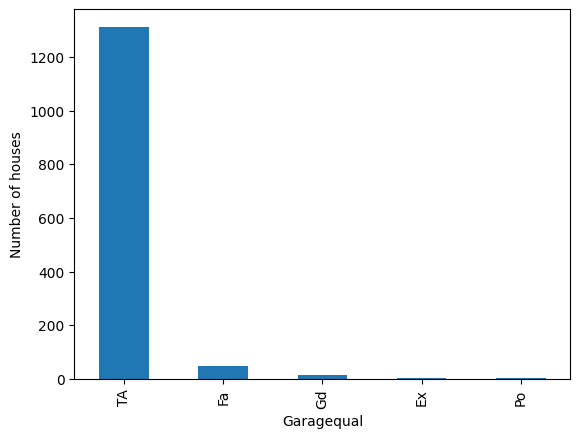

In [14]:
df['GarageQual'].value_counts().plot.bar()
plt.xlabel('Garagequal')
plt.ylabel('Number of houses')
plt.show()

In [15]:
df['GarageQual'].mode()

0    TA
Name: GarageQual, dtype: object

<Axes: ylabel='Density'>

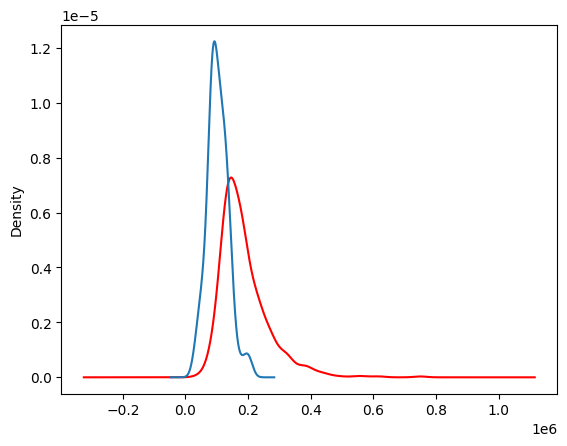

In [29]:
fig = plt.figure()
ax = fig.add_subplot(111)

df[df['GarageQual'] == 'TA']['SalePrice'].plot(kind = 'kde', ax = ax, color = 'red')
df[df['GarageQual'].isnull()]['SalePrice'].plot(kind = 'kde', ax = ax)


In [30]:
temp = df[df['GarageQual'] == 'TA']['SalePrice']

In [31]:
df['GarageQual'].fillna('TA', inplace=True)

<Axes: xlabel='GarageQual'>

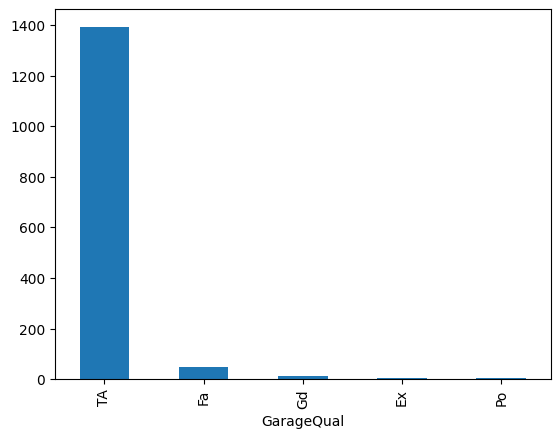

In [32]:
df['GarageQual'].value_counts().plot(kind = 'bar')

<Axes: ylabel='Density'>

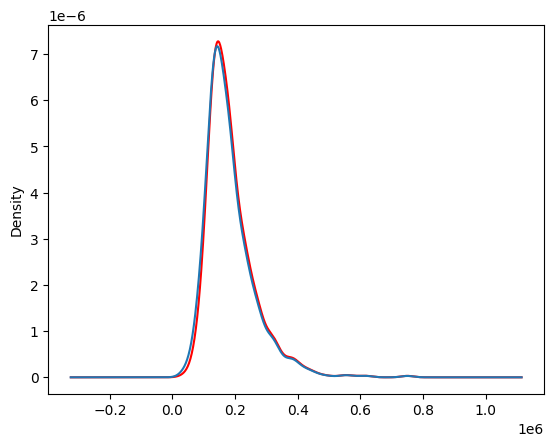

In [35]:
fig = plt.figure()
ax = fig.add_subplot(111)

temp.plot(kind = 'kde', ax = ax, color = 'red')
df[df['GarageQual'] == 'TA']['SalePrice'].plot(kind = 'kde')



In [36]:
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer

x_train,x_test,y_train,y_test = train_test_split(
    df.drop(columns=['SalePrice']),df['SalePrice'], random_state=42, test_size=0.2
)

In [37]:
imputer = SimpleImputer(strategy = 'most_frequent')

In [39]:
x_train = imputer.fit_transform(x_train)
x_test = imputer.fit_transform(x_test)

In [40]:
imputer.statistics_

array(['Gd', 'TA'], dtype=object)

In [41]:
# from sklearn.model_selection import train_test_split
# X_train, X_test,y_train,y_test =train_test_split(df.drop(columns=['SalePrice']),df['SalePrice'],test_size=0.2)

# from sklearn.impute import SimpleImputer

# imputer = SimpleImputer(jstrategy='constant', fill_value='Missing')

# X_train = imputer.fit_transform(X_train)
# X_test = imputer.transform(X_train)

# imputer.statistics
